# MODELING xG FOR PLAYER SCORING ABILITY

MODEL B: Model A + generic shooter ability

This notebook is to be run once you have a dataset that includes the FIFA scoring ratings for each player in the statsbomb dataset.

If not, run the script called Player_scoring _bility.ipynb, to get the dataset for the player scoring ability as shown on the FIFA index.

## DATA PREPROCESSING

In [1]:
import pandas as pd

shots = pd.read_csv("~/Desktop/Football_Stats/xG/datasets/shots.csv")
shots.head(10)

,location,player,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,0,0,0,0,1,0,94.5,42.9,25.664372,17.611035
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,0,0,0,0,1,0,93.5,48.4,27.799460,15.648789
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,0,0,0,0,1,0,89.8,22.3,35.004714,11.297814
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,0,0,0,0,1,0,98.2,26.0,25.908300,14.904419
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,0,0,0,0,1,0,105.7,24.2,21.310326,14.633756
5,"[115.1, 45.5]",Pedro Eliezer Rodríguez Ledesma,3958.0,Right Wing,0,0,0.400975,0,0,0,...,0,0,0,0,1,0,115.1,45.5,7.366139,45.695267
6,"[103.9, 23.5]",Aaron Ramsey,3517.0,Right Wing,0,0,0.023207,0,0,0,...,0,0,0,0,1,0,103.9,23.5,23.053416,14.029443
7,"[87.3, 42.5]",Kurt Happy Zouma,3456.0,Right Center Back,0,0,0.020538,0,0,0,...,0,0,0,0,1,0,87.3,42.5,32.795427,13.868931
8,"[92.6, 47.4]",Pedro Eliezer Rodríguez Ledesma,3958.0,Right Wing,0,1,0.033888,0,0,0,...,0,0,0,0,1,0,92.6,47.4,28.381684,15.516625
9,"[95.7, 28.2]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,1,0.026702,0,0,0,...,0,0,0,0,1,0,95.7,28.2,27.013515,15.236166


In [2]:
players = pd.read_csv("~/Desktop/Football_Stats/xG/datasets/player_ratings.csv")
players = players[["player_id", "player", "Att. Position", "Finishing", "Shot Power", "Long Shots", "Volleys", "Penalties", "Heading"]].copy()
players.head(10)

,player_id,player,Att. Position,Finishing,Shot Power,Long Shots,Volleys,Penalties,Heading
0,3517.0,Aaron Ramsey,83.0,75.0,81.0,75.0,79.0,75.0,58.0
1,3668.0,Theo Walcott,79.0,82.0,75.0,69.0,72.0,74.0,55.0
2,5594.0,Branislav Ivanović,61.0,57.0,73.0,62.0,48.0,58.0,87.0
3,3381.0,Nemanja Matić,68.0,64.0,78.0,75.0,74.0,69.0,77.0
4,3621.0,Eden Hazard,84.0,81.0,79.0,82.0,79.0,86.0,57.0
5,6623.0,Loïc Rémy,81.0,83.0,78.0,77.0,71.0,78.0,81.0
6,28100.0,Ramires Santos do Nascimento,77.0,68.0,77.0,72.0,75.0,85.0,64.0
7,11117.0,Scott Sinclair,74.0,72.0,73.0,65.0,65.0,82.0,69.0
8,3604.0,Olivier Giroud,84.0,84.0,84.0,76.0,81.0,81.0,86.0
9,3394.0,Laurent Koscielny,31.0,32.0,54.0,47.0,35.0,51.0,84.0


In [3]:
print("Unique shot players:", shots["player_id"].nunique())
print("Unique rated players:", players["player_id"].nunique())

missing_ids = (
    shots.loc[
        ~shots["player_id"].isin(players["player_id"]),
        ["player_id", "player"]
    ]
    .drop_duplicates()
)

print(f"Players missing ratings: {len(missing_ids)}")
if len(missing_ids) > 0:
    print(missing_ids)

Unique shot players: 452
Unique rated players: 452
Players missing ratings: 0


MERGING BOTH DATASETS

In [4]:
shots_extended = pd.merge(shots, players, on='player_id', how='left', validate="many_to_one")
shots_extended.head()

,location,player_x,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,distance,angle,player_y,Att. Position,Finishing,Shot Power,Long Shots,Volleys,Penalties,Heading
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,25.664372,17.611035,Aaron Ramsey,83.0,75.0,81.0,75.0,79.0,75.0,58.0
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,27.799460,15.648789,Francesc Fàbregas i Soler,80.0,76.0,77.0,78.0,81.0,80.0,74.0
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,35.004714,11.297814,Alexis Alejandro Sánchez Sánchez,85.0,83.0,82.0,79.0,78.0,77.0,65.0
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,25.908300,14.904419,Diego da Silva Costa,88.0,88.0,83.0,69.0,81.0,76.0,82.0
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,21.310326,14.633756,Theo Walcott,79.0,82.0,75.0,69.0,72.0,74.0,55.0


In [5]:
shots_extended["Shooting"] = (shots_extended["Att. Position"] + shots_extended["Finishing"] 
                                + shots_extended["Shot Power"] + shots_extended["Long Shots"] + shots_extended["Volleys"] 
                                + shots_extended["Penalties"] + shots_extended["Heading"]) / 7 
# I am including "Heading" since some scoring contexts are aerial won
# meaning the player's heading accuracy is necessary for evaluating their scoring ability in such situations

shots_extended.drop(columns=["Att. Position", "Finishing", "Shot Power", "Long Shots", "Volleys", "Penalties", "Heading"], inplace=True)
shots_extended.head()

,location,player_x,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle,player_y,Shooting
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,0,0,1,0,94.5,42.9,25.664372,17.611035,Aaron Ramsey,75.142857
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,0,0,1,0,93.5,48.4,27.799460,15.648789,Francesc Fàbregas i Soler,78.000000
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,0,0,1,0,89.8,22.3,35.004714,11.297814,Alexis Alejandro Sánchez Sánchez,78.428571
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,0,0,1,0,98.2,26.0,25.908300,14.904419,Diego da Silva Costa,81.000000
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,0,0,1,0,105.7,24.2,21.310326,14.633756,Theo Walcott,72.285714


In [6]:
print(f"{shots_extended.shape}")

(9908, 32)


In [7]:
shots_extended.drop(["player_y"], axis=1, inplace=True)
shots_extended.head()

,location,player_x,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle,Shooting
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,0,0,0,1,0,94.5,42.9,25.664372,17.611035,75.142857
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,0,0,0,1,0,93.5,48.4,27.799460,15.648789,78.000000
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,0,0,0,1,0,89.8,22.3,35.004714,11.297814,78.428571
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,0,0,0,1,0,98.2,26.0,25.908300,14.904419,81.000000
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,0,0,0,1,0,105.7,24.2,21.310326,14.633756,72.285714


Normalizing distance angle and shooting values

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
norm_cols = ["distance", "angle", "Shooting"]
shots_extended[norm_cols] = scaler.fit_transform(shots_extended[norm_cols])
shots_extended.head()

,location,player_x,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle,Shooting
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,0,0,0,1,0,94.5,42.9,0.381953,0.109927,0.864301
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,0,0,0,1,0,93.5,48.4,0.414913,0.097636,0.906054
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,0,0,0,1,0,89.8,22.3,0.526142,0.070383,0.912317
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,0,0,0,1,0,98.2,26.0,0.385719,0.092974,0.949896
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,0,0,0,1,0,105.7,24.2,0.314739,0.091278,0.822547


In [9]:
shots_extended.goal.value_counts()

goal
0    8920
1     988
Name: count, dtype: int64

In [10]:
# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20, 10))
# axs = axs.ravel()

# axs[0].plot(shots_extended['goal'], shots_extended['Shooting'], color='red')
# axs[0].set_title('Shooting vs Goal')

# axs[1].plot(shots_extended['shot_statsbomb_xg'].sort_values(ascending=False), shots_extended['Shooting'], color='red')
# axs[1].set_title('Shooting vs xG')

# axs[2].plot(shots_extended['distance'].sort_values(ascending=False), shots_extended['Shooting'], color='red')
# axs[2].set_title('Shooting vs Distance')

# axs[3].plot(shots_extended['angle'].sort_values(ascending=False), shots_extended['Shooting'], color='red')
# axs[3].set_title('Shooting vs Angle')

# axs[4].plot(shots_extended['shot_type_Penalty'], shots_extended['Shooting'], color='red')
# axs[4].set_title('Shooting vs Penalty')

# axs[5].plot(shots_extended['shot_type_Free Kick'], shots_extended['Shooting'], color='red')
# axs[5].set_title('Shooting vs Free Kick')

# axs[6].plot(shots_extended['shot_type_Open Play'], shots_extended['Shooting'], color='red')
# axs[6].set_title('Shooting vs Open Play')

# plt.tight_layout()

In [11]:
shots_extended.drop(['location', 'player_x', 'player_id', 'position'], axis=1, inplace=True)
correlations = shots_extended.corrwith(shots_extended['Shooting']).sort_values(ascending=False)

print(correlations)

Shooting                        1.000000
shot_body_part_Right Foot       0.099987
shot_statsbomb_xg               0.099495
goal                            0.065523
shot_type_Penalty               0.056998
shot_type_Free Kick             0.051839
shot_technique_Lob              0.040469
shot_technique_Normal           0.032657
shot_technique_Backheel         0.030691
shot_body_part_Left Foot        0.015162
shot_follows_dribble            0.011961
shot_technique_Overhead Kick    0.008729
distance                        0.006188
x                               0.000510
shot_technique_Diving Header   -0.002233
shot_open_goal                 -0.004555
shot_first_time                -0.006622
shot_body_part_Other           -0.007710
shot_type_Corner               -0.010519
y                              -0.012127
shot_technique_Volley          -0.031830
shot_technique_Half Volley     -0.033822
angle                          -0.055470
shot_type_Open Play            -0.071500
under_pressure  

/Users/nanakwamekankam/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/nanakwamekankam/.local/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/nanakwamekankam/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pas

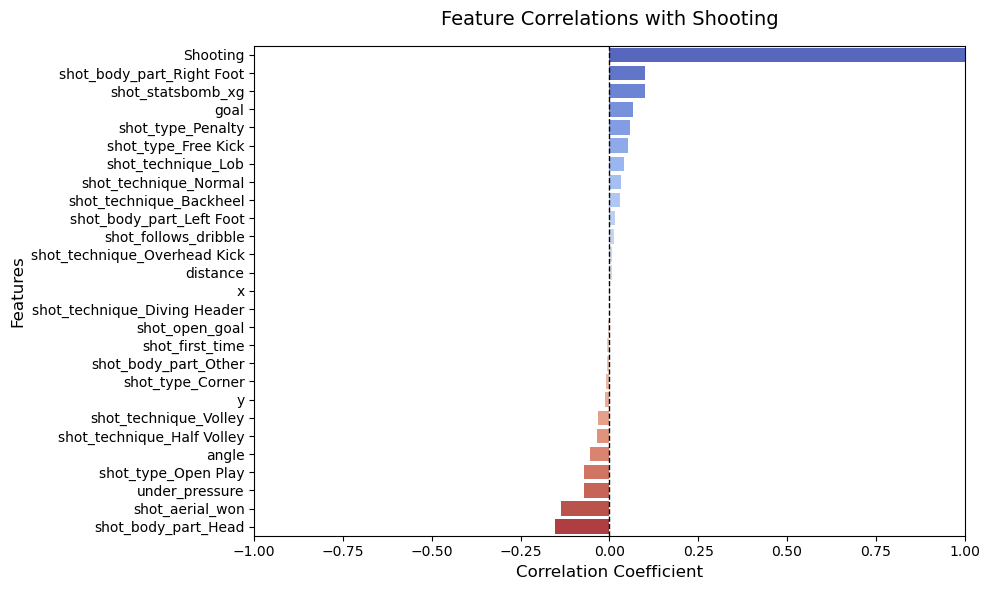

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm', hue=correlations.index, legend=False)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title(f'Feature Correlations with Shooting', fontsize=14, pad=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(-1, 1) 
plt.tight_layout()

plt.show()

# checks out

# angle is not a linear variable 

# more efficeintly work with angle

# get a feature space for every player's preferred foot

# drop shot_open goal or headers to argue that the introduction/loss of an important feature does not yeild significant changes in accuracy 

In [13]:
shots_goals = pd.DataFrame(shots_extended[shots_extended['goal'] == 1])

shots_goals.shape

(988, 27)

In [14]:
shots_extended.to_csv('~/Desktop/Football_Stats/xG/shots_extended.csv', index=False)

In [15]:
y = shots_extended['goal']
X = shots_extended.drop(['goal', 'shot_statsbomb_xg'], axis=1)

print(f"{X.shape}, {y.shape}")

(9908, 25), (9908,)


In [16]:
X.columns

Index(['shot_aerial_won', 'shot_first_time', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty', 'x', 'y', 'distance', 'angle', 'Shooting'],
      dtype='object')

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
cordinates = X_test[['x', 'y']] # for model visualizations
X_train.drop(["x", "y"], axis=1, inplace=True)
X_test.drop(["x", "y"], axis=1, inplace=True)
X_train.head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,Shooting
3333,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.359848,0.114180,0.749478
2166,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0.488520,0.086901,0.736952
8009,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.367416,0.077479,0.807933
8299,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.450847,0.091271,0.703549
2825,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.895973,0.046719,0.912317


In [18]:
X_test.head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,Shooting
7150,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0.464293,0.091165,0.839248
7359,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0.301057,0.107210,0.521921
360,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.400985,0.096612,0.745303
1253,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0.295994,0.139400,0.864301
3026,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0.221391,0.113413,0.993737


## MODELING

### LOGISTIC REGRESSION

In [19]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
y_log= logistic_regressor.predict_proba(X_test)[:,1]
goal_log = logistic_regressor.predict(X_test)
y_log[:10]

array([0.02725813, 0.04842057, 0.03526721, 0.05695222, 0.1281364 ,
       0.04817436, 0.02778572, 0.02892825, 0.34891415, 0.18348863])

In [21]:
log_df = X_test.copy()
log_df['xG'] = y_log
log_df.iloc[830]

shot_aerial_won                 0.000000
shot_first_time                 0.000000
under_pressure                  0.000000
shot_open_goal                  0.000000
shot_follows_dribble            0.000000
shot_body_part_Head             0.000000
shot_body_part_Left Foot        0.000000
shot_body_part_Other            0.000000
shot_body_part_Right Foot       1.000000
shot_technique_Backheel         0.000000
shot_technique_Diving Header    0.000000
shot_technique_Half Volley      0.000000
shot_technique_Lob              0.000000
shot_technique_Normal           1.000000
shot_technique_Overhead Kick    0.000000
shot_technique_Volley           0.000000
shot_type_Corner                0.000000
shot_type_Free Kick             0.000000
shot_type_Open Play             1.000000
shot_type_Penalty               0.000000
distance                        0.358252
angle                           0.093267
Shooting                        0.874739
xG                              0.051271
Name: 447, dtype

In [22]:
print(f"goal: {y_test.iloc[100]}, predicted:{goal_log[100]}")

goal: 0, predicted:0


In [23]:
y_train.value_counts(normalize=True)

goal
0    0.900649
1    0.099351
Name: proportion, dtype: float64

## RANDOM FOREST

In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    # class_weight='balanced_subsample',
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
# try tuning parameters
random_forest.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_rf = random_forest.predict_proba(X_test)[:,1]
goal_rf = random_forest.predict(X_test)
y_rf[:10]

array([0.04965118, 0.03864716, 0.02404836, 0.05980899, 0.09736109,
       0.0359517 , 0.02972743, 0.03313849, 0.37019823, 0.22560225])

In [26]:
rf_df = pd.DataFrame()
rf_df['Goal'] = y_test.copy()
rf_df['xG'] = y_rf
rf_df.iloc[830]

Goal    0.000000
xG      0.040244
Name: 447, dtype: float64

In [27]:
print(f"goal: {y_test.iloc[100]}, predicted:{goal_rf[100]}")

goal: 0, predicted:0


## XGBOOST

Run the following code if you don't have xgboost installed in your environment

In [28]:
# % conda install -c conda-forge xgboost

In [29]:
import xgboost as xgb

In [30]:
xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic',
    importance_type='gain'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
y_xgb = xgb.predict_proba(X_test)[:,1]
goal_xgb = xgb.predict(X_test)

In [32]:
xgb_df = pd.DataFrame()
xgb_df['Goal'] = y_test.copy()
xgb_df['xG'] = y_rf
xgb_df.iloc[830]

Goal    0.000000
xG      0.040244
Name: 447, dtype: float64

In [33]:
print(f"goal: {y_test.iloc[100]}, predicted:{goal_xgb[100]}")

goal: 0, predicted:0


## CATBOOST

Run the following code if you don't have CatBoost installed in your environment

In [34]:
# %conda install -c conda-forge catboost

In [35]:
from catboost import CatBoostClassifier, Pool


In [36]:
catBoost = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=10)

train_pool = Pool(X_train, y_train)
eval_pool = Pool(X_test, y_test)
catBoost.fit(train_pool)

0:	learn: 0.5923581	total: 63.8ms	remaining: 6.32s
10:	learn: 0.2959557	total: 79.3ms	remaining: 642ms
20:	learn: 0.2666612	total: 96.1ms	remaining: 361ms
30:	learn: 0.2568249	total: 158ms	remaining: 352ms
40:	learn: 0.2530307	total: 188ms	remaining: 271ms
50:	learn: 0.2505600	total: 206ms	remaining: 198ms
60:	learn: 0.2471448	total: 222ms	remaining: 142ms
70:	learn: 0.2447911	total: 237ms	remaining: 96.7ms
80:	learn: 0.2417650	total: 252ms	remaining: 59.2ms
90:	learn: 0.2392119	total: 273ms	remaining: 27ms
99:	learn: 0.2364428	total: 291ms	remaining: 0us


In [37]:
y_cat = catBoost.predict_proba(X_test)[:,1]
goal_cat = catBoost.predict(X_test)

In [38]:
cat_df = pd.DataFrame()
cat_df['Goal'] = y_test.copy()
cat_df['xG'] = y_cat
cat_df.iloc[830]

Goal    0.000000
xG      0.043663
Name: 447, dtype: float64

In [39]:
print(f"goal: {y_test.iloc[100]}, predicted:{goal_cat[100]}")

goal: 0, predicted:0


# MODEL EVAULATION

For Logistic Regression

In [40]:
log_df.sort_values(by='xG', ascending=False).head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,Shooting,xG
1369,0,1,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0.020766,0.805168,0.866388,0.914688
9725,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0.026552,0.819744,0.889353,0.910034
9284,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0.031821,0.720166,0.860125,0.870965
3931,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0.038004,0.667722,0.791232,0.847435
9269,0,1,1,1,0,0,1,0,0,0,...,0,1,0,0,1,0,0.028771,0.850506,0.772443,0.845509


In [41]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, goal_log):.3f}\nLog Loss: {log_loss(y_test, y_log):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_log):.3f}\nBrier Score: {brier_score_loss(y_test, y_log):.3f}")

Accuracy: 0.909
Log Loss: 0.271
ROC_AUC Score: 0.777
Brier Score: 0.076


For Random Forest

In [42]:
rf_df.sort_values(by='xG', ascending=False).head()
print(f"Accuracy: {accuracy_score(y_test, goal_rf):.3f}\nLog Loss: {log_loss(y_test, y_rf):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_rf):.3f}\nBrier Score: {brier_score_loss(y_test, y_rf):.3f}")

Accuracy: 0.908
Log Loss: 0.276
ROC_AUC Score: 0.766
Brier Score: 0.078


For XGBoost

In [43]:
xgb_df.sort_values(by='xG', ascending=False).head()
print(f"Accuracy: {accuracy_score(y_test, goal_xgb):.3f}\nLog Loss: {log_loss(y_test, y_xgb):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_xgb):.3f}\nBrier Score: {brier_score_loss(y_test, y_xgb):.3f}")

Accuracy: 0.906
Log Loss: 0.279
ROC_AUC Score: 0.759
Brier Score: 0.078


For CatBoost

In [44]:
cat_df.sort_values(by='xG', ascending=False).head()
print(f"Accuracy: {accuracy_score(y_test, goal_cat):.3f}\nLog Loss: {log_loss(y_test, y_cat):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_cat):.3f}\nBrier Score: {brier_score_loss(y_test, y_cat):.3f}")

Accuracy: 0.910
Log Loss: 0.272
ROC_AUC Score: 0.774
Brier Score: 0.076


Confusion Matrices

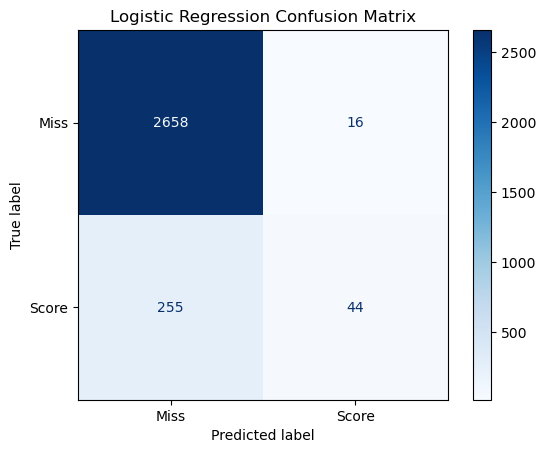

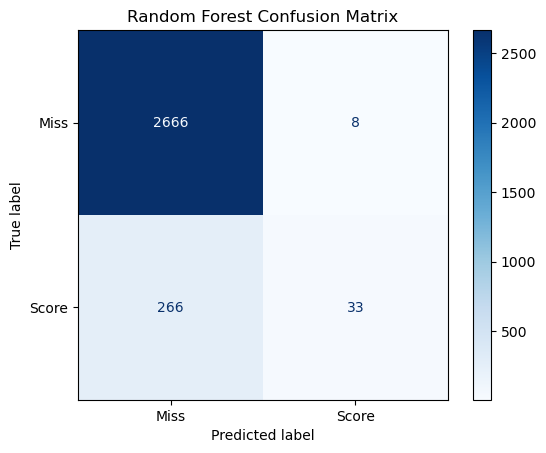

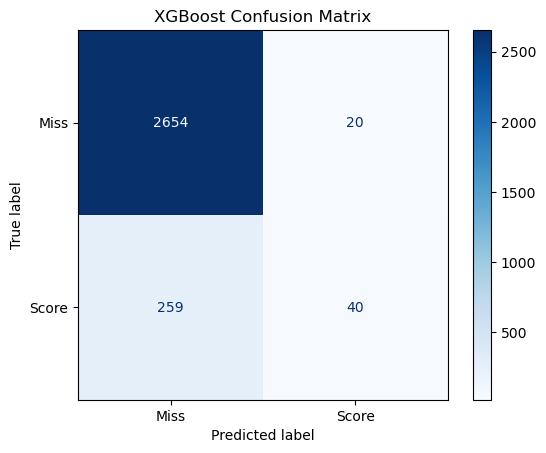

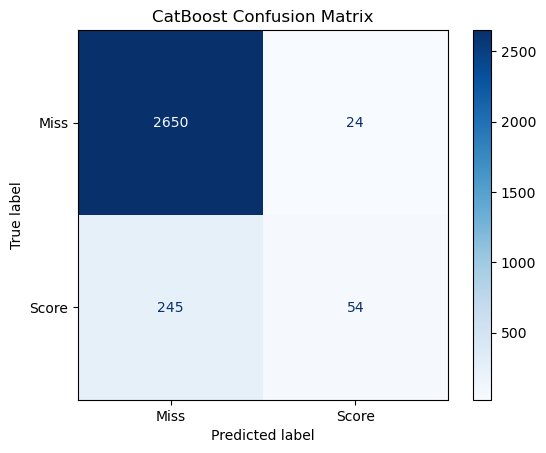

In [45]:
goal_dataframes = {"Logistic Regression": goal_log,
                   "Random Forest": goal_rf,
                   "XGBoost": goal_xgb,
                   "CatBoost": goal_cat}

for key, value in goal_dataframes.items():
    cm = confusion_matrix(y_test, value)
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    # Plotting
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miss', 'Score'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{key} Confusion Matrix")
    plt.show()


Calibration Curves

In [46]:
# %conda install -c conda-forge matplotlib

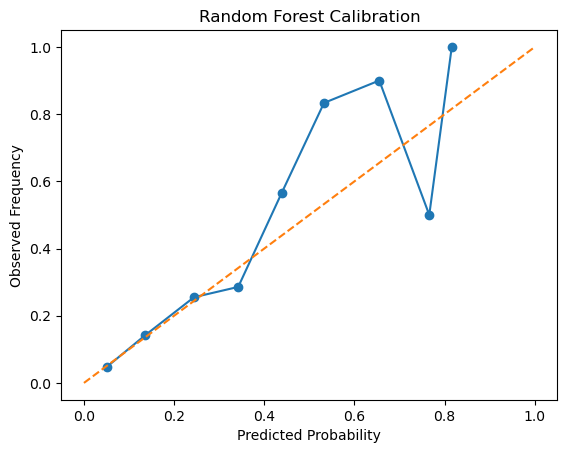

In [47]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_rf, prob_pred = calibration_curve(
    y_test,
    y_rf,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Random Forest Calibration")
plt.show()

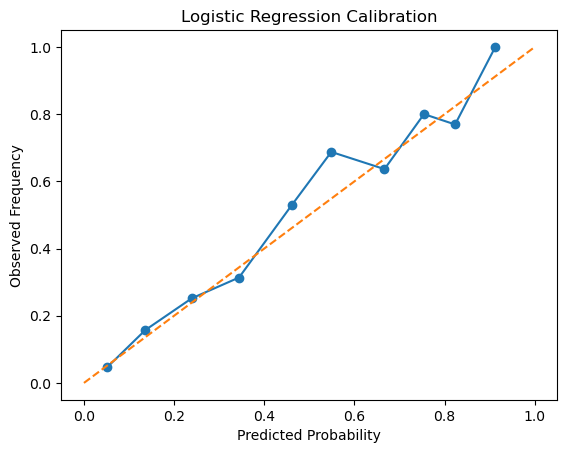

In [48]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_log,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Logistic Regression Calibration")
plt.show()

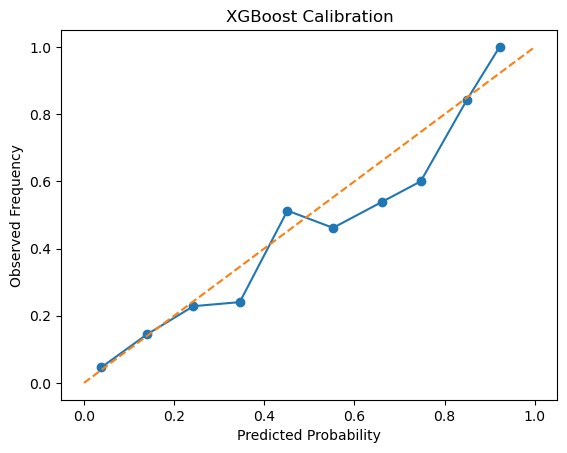

In [49]:
prob_xgb, prob_pred = calibration_curve(
    y_test,
    y_xgb,
    n_bins=10
)

plt.plot(prob_pred, prob_xgb, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("XGBoost Calibration")
plt.show()

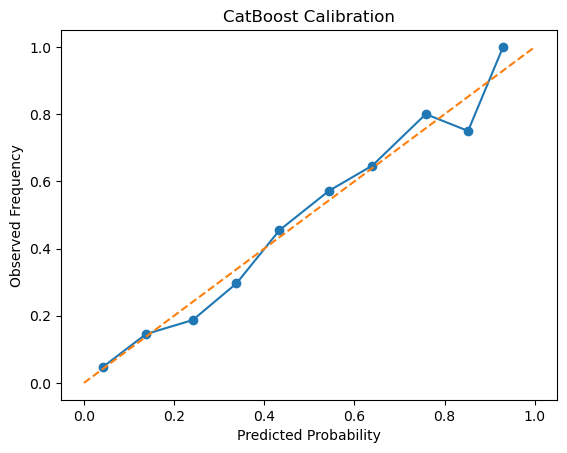

In [50]:
prob_cat, prob_pred = calibration_curve(
    y_test,
    y_cat,
    n_bins=10
)

plt.plot(prob_pred, prob_cat, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("CatBoost Calibration")
plt.show()

## Feature Importance

### For Logistic Regression

Logistic regression uses linear regression. Hence, feature importance can be derived from the rank of the size of the coefficients.

In [51]:
X_test.columns

Index(['shot_aerial_won', 'shot_first_time', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty', 'distance', 'angle', 'Shooting'],
      dtype='object')

Beta coefficients: [-0.54568772  0.09800691 -0.01091655  0.81460067  0.35915223 -0.68691053
  0.10615871  0.10926681  0.18353004 -0.38649044  1.12192723 -0.32795561
  0.82573355  0.08000744 -1.01373992 -0.58743722  0.63360135 -0.93542341
 -1.40774166  1.42160875 -5.96704021  3.43718575  1.05447504]

Bias: -0.8790597937892409


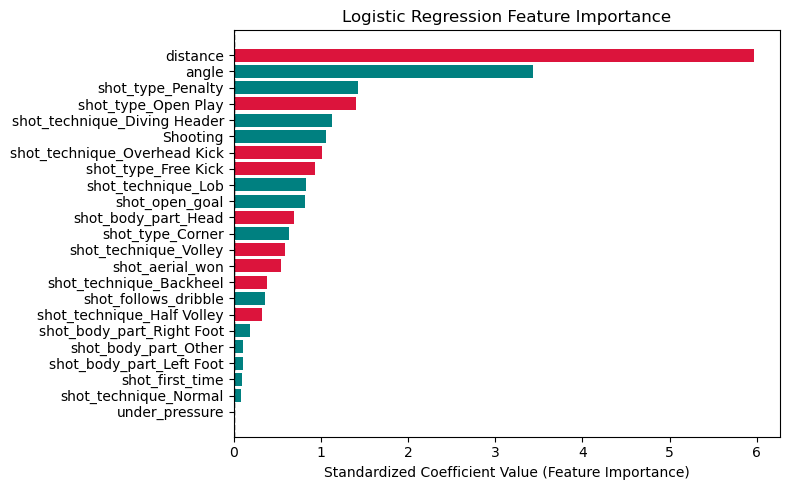

In [52]:
coefficients = logistic_regressor.coef_.flatten()
# coefficients = logistic_regressor.coef_[0]
print(f"Beta coefficients: {coefficients}\n")


bias = logistic_regressor.intercept_[0]
print(f"Bias: {bias}")

importance_df = pd.DataFrame(
    {"Feature": X_test.columns, "Coefficient": coefficients}
)

importance_df["Abs_Coefficient"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values(by="Abs_Coefficient", ascending=True)

plt.figure(figsize=(8, 5))
colors = ["crimson" if c < 0 else "teal" for c in importance_df["Coefficient"]]
plt.barh(importance_df["Feature"], importance_df["Abs_Coefficient"], color=colors)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized Coefficient Value (Feature Importance)")
plt.title("Logistic Regression Feature Importance")
plt.tight_layout()
plt.show()

### For Random Forest

The default metric returned when .feature_importances_ is called is the Mean Decrease in Impurity. This is generally the mean reduction in data impurity during the split of a node on the specified feature. 

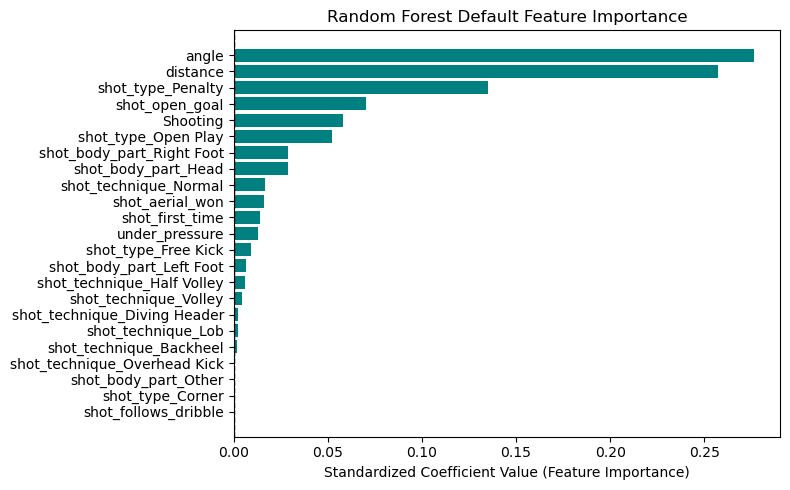

In [53]:
importance = pd.DataFrame( {"Feature": X_test.columns, "Importance": random_forest.feature_importances_}
).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized Coefficient Value (Feature Importance)")
plt.title("Random Forest Default Feature Importance")
plt.tight_layout()
plt.show()

Naturally, you'd expect this to favor features with high cardinality. So, the better metric will be to permutate and compute. Here, for every feature, random data points are generated based on the true distribution. This breaks the mathematical relationship between that specific feature and the target variable, while preserving the exact distribution of the data. The forest is run again and the reduction in the evaulation metric of choice(accuracy, roc auc, brier, f1, etc.), is calcluated. This is done multiple times to account for randomness and the results are averaged out.

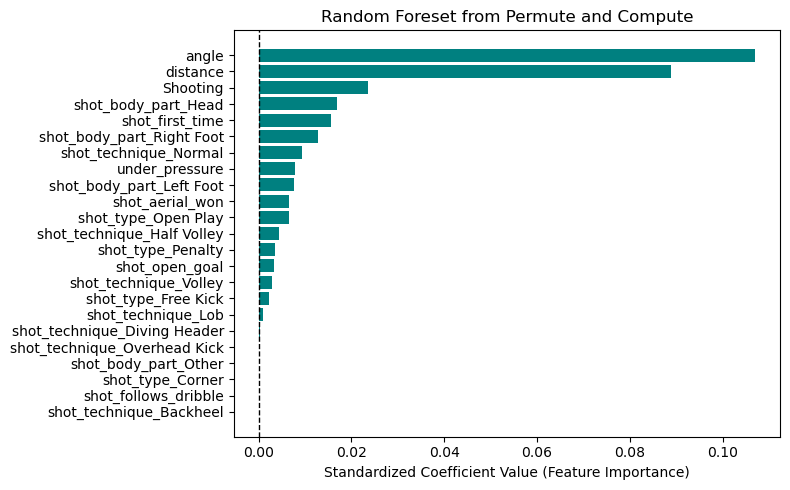

In [54]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    random_forest,
    X_train,         
    y_train,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc"   # accuracy, log loss, or brier score
)

importance = pd.DataFrame( {"Feature": X_test.columns, "Importance": result.importances_mean}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized Coefficient Value (Feature Importance)")
plt.title("Random Foreset from Permute and Compute")
plt.tight_layout()
plt.show()

This gives are better importance metric of a feature without the heavy influence of cardinality.

### For XGBoost

The default metric for model importance in XGBoost is the gain. Here, for everynode where the specific feature is used to split the node is considered, and the difference in training loss before or after the split is measured accross all trees. Then divides it by the total number of splits made by that feature to provide an average gain.

**However, consider that xgboost also uses cover to measure a feature's importance by showing how much the feature is responsible for making decisions that affect a vast majority of your training samples. For a single split, the "cover" is calculated using the second-order gradients of the loss function for the samples in that node. For classification, it relates to the confidence of the predictions.**

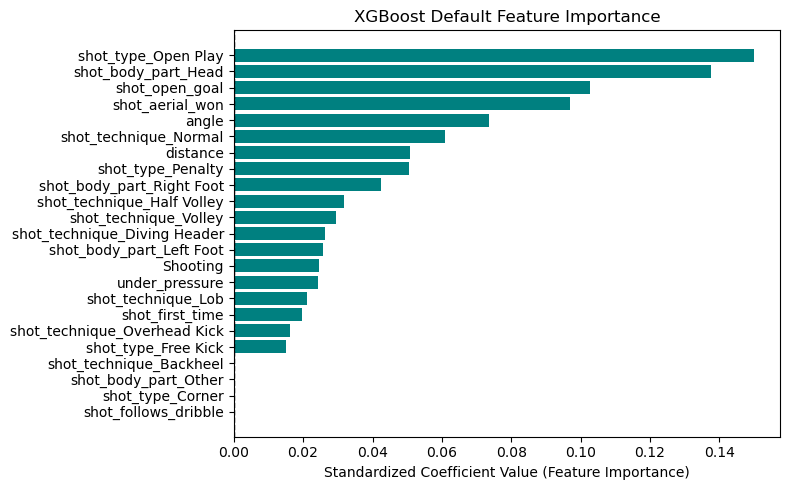

In [55]:
importance = pd.DataFrame( {"Feature": X_test.columns, 
                            "Importance": xgb.feature_importances_}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized Coefficient Value (Feature Importance)")
plt.title("XGBoost Default Feature Importance")
plt.tight_layout()
plt.show()


Intuitively, most of the datapoints are boolian (Meaning they only take 1s or 0s as inputs). While features like distance, and angle and shooting have high cardinality. I think feature importance techniques that validate based on splits will not offer a consistent basis for all features. 

Hence, I think permute and compute is the best way forward. It does the same thing for each feature: it shuffles the values to match the original distribution, runs the algorithm and averages the evaluation metric of choice against the base line model multiple times and ranks the features afterwards. 

CatBoost has two ways of measuring feature importance. Like all decision tree based models, it uses an algortithm that measures the effect of a decision validated on each feature(called "PredictionValuesChange"), which I am going to ignore. Then a second called "LossFunctionChange", also known as "feature dropout", that measures the degradation in the model's loss/metric (e.g., RMSE, Logloss) when a specific feature is removed from the model. A larger drop indicates higher importance.

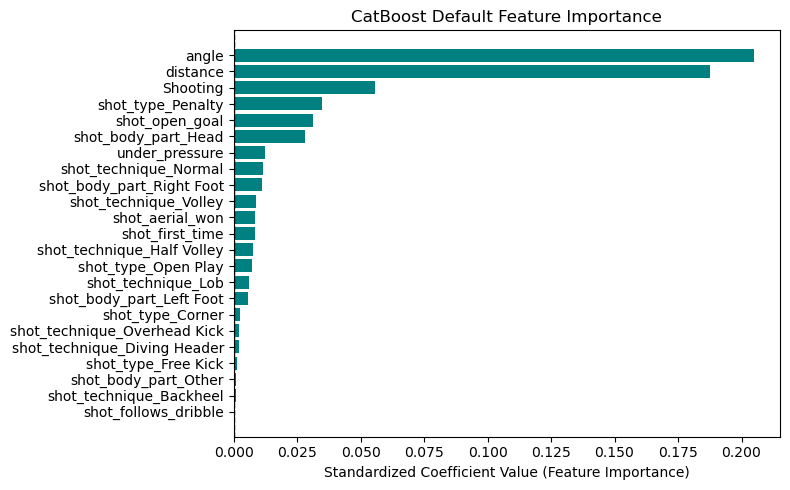

In [56]:
importance = catBoost.get_feature_importance(data=train_pool , type="LossFunctionChange")

importance = pd.DataFrame( {"Feature": X_test.columns, 
                            "Importance": importance*10}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized Coefficient Value (Feature Importance)")
plt.title("CatBoost Default Feature Importance")
plt.tight_layout()
plt.show()


## PERMUTE AND COMPUTE

                         Feature  Importance
19             shot_type_Penalty    0.001925
10  shot_technique_Diving Header    0.001976
22                      Shooting    0.005985
15         shot_technique_Volley    0.006165
0                shot_aerial_won    0.006307
17           shot_type_Free Kick    0.009002
18           shot_type_Open Play    0.013274
5            shot_body_part_Head    0.017467
21                         angle    0.036329
20                      distance    0.161330


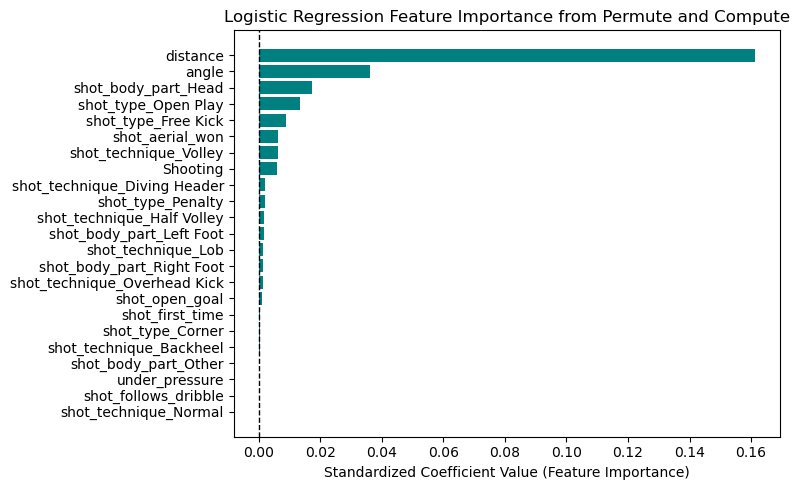

                      Feature  Importance
1             shot_first_time    0.005211
8   shot_body_part_Right Foot    0.005592
6    shot_body_part_Left Foot    0.006305
0             shot_aerial_won    0.007012
13      shot_technique_Normal    0.010764
18        shot_type_Open Play    0.011068
5         shot_body_part_Head    0.033505
22                   Shooting    0.063546
20                   distance    0.157043
21                      angle    0.170951


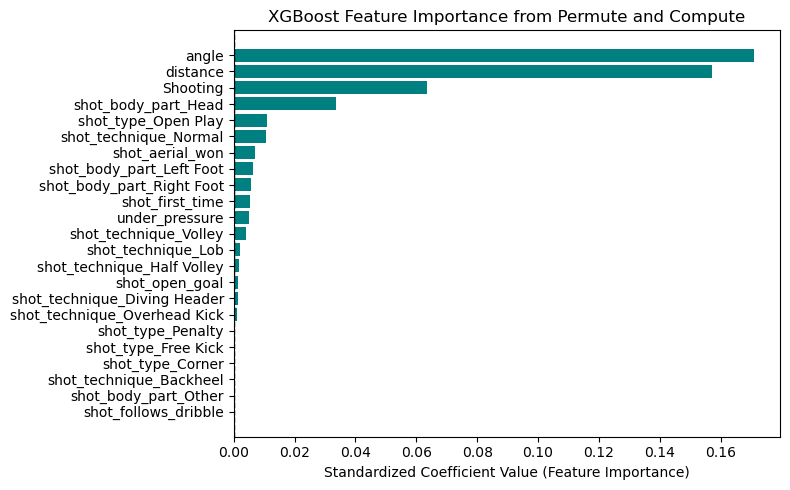

                      Feature  Importance
0             shot_aerial_won    0.006484
6    shot_body_part_Left Foot    0.007681
2              under_pressure    0.007910
13      shot_technique_Normal    0.009420
8   shot_body_part_Right Foot    0.012716
1             shot_first_time    0.015488
5         shot_body_part_Head    0.016954
22                   Shooting    0.023641
20                   distance    0.088802
21                      angle    0.107024


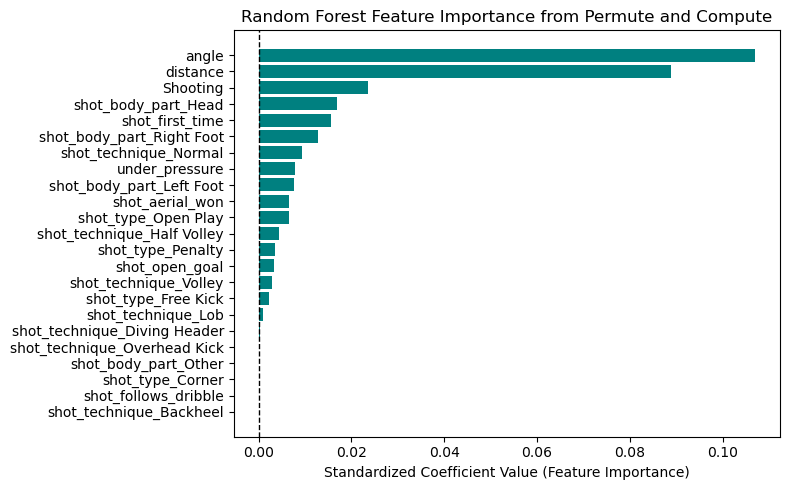

                       Feature  Importance
11  shot_technique_Half Volley    0.004841
0              shot_aerial_won    0.005840
1              shot_first_time    0.006339
2               under_pressure    0.008772
8    shot_body_part_Right Foot    0.010291
13       shot_technique_Normal    0.011074
5          shot_body_part_Head    0.020065
22                    Shooting    0.033772
21                       angle    0.115162
20                    distance    0.121082


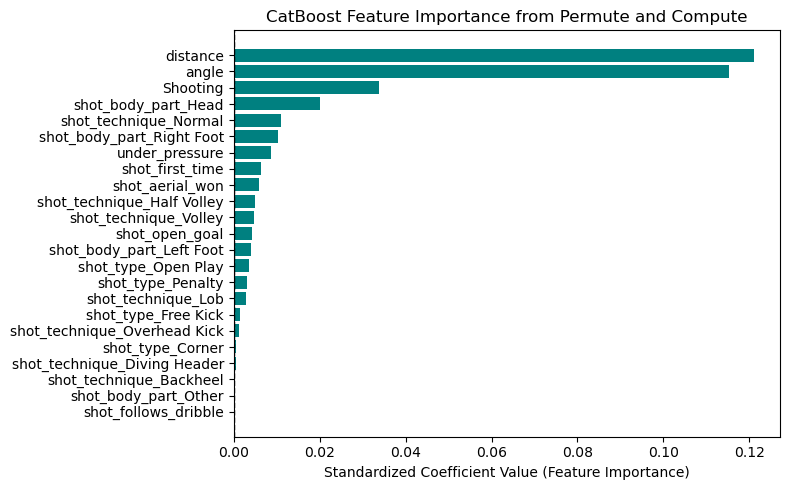

In [57]:
from sklearn.inspection import permutation_importance

models = {"Logistic Regression": logistic_regressor,
          "XGBoost": xgb,
          "Random Forest": random_forest,
          "CatBoost": catBoost}

for name, model in models.items():
    result = permutation_importance(
        model,
        X_train,         
        y_train,
        n_repeats=50,
        random_state=42,
        scoring="roc_auc"   # accuracy, log loss, or brier score
    )

    importance = pd.DataFrame( {"Feature": X_test.columns, 
                                "Importance": result.importances_mean}).sort_values(by="Importance", ascending=True)

    print(importance.tail(10)) # get the top 8 performing features for justification purposes
    # except distanc and angle (see xG_feature_dropout.ipynb)

    plt.figure(figsize=(8, 5))
    plt.barh(importance["Feature"], importance["Importance"], color="teal")
    plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Standardized Coefficient Value (Feature Importance)")
    plt.title(f"{name} Feature Importance from Permute and Compute")
    plt.tight_layout()
    plt.show()



# MODEL VISUALIZATIONS

In [58]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=1
)
colors = ['red', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors)
sc = pitch.scatter

In [59]:
# import numpy as np

# dataframes = {
#     'Logistic Regression': log_df,
#     'Random Forest': rf_df,
#     'XGBoost': xgb_df,
#     'CatBoost': cat_df
# }

# for name, df in dataframes.items():

#     fig, ax = pitch.draw(figsize=(10,8))
#     sc = pitch.scatter(
#         cordinates['x'], cordinates['y'], c=df['xG'],
#         cmap=cmap, edgecolors='black', linewidth=0.5, s=100, ax=ax
#     )

#     cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
#     cbar.set_label(f'{name} xG Probability')

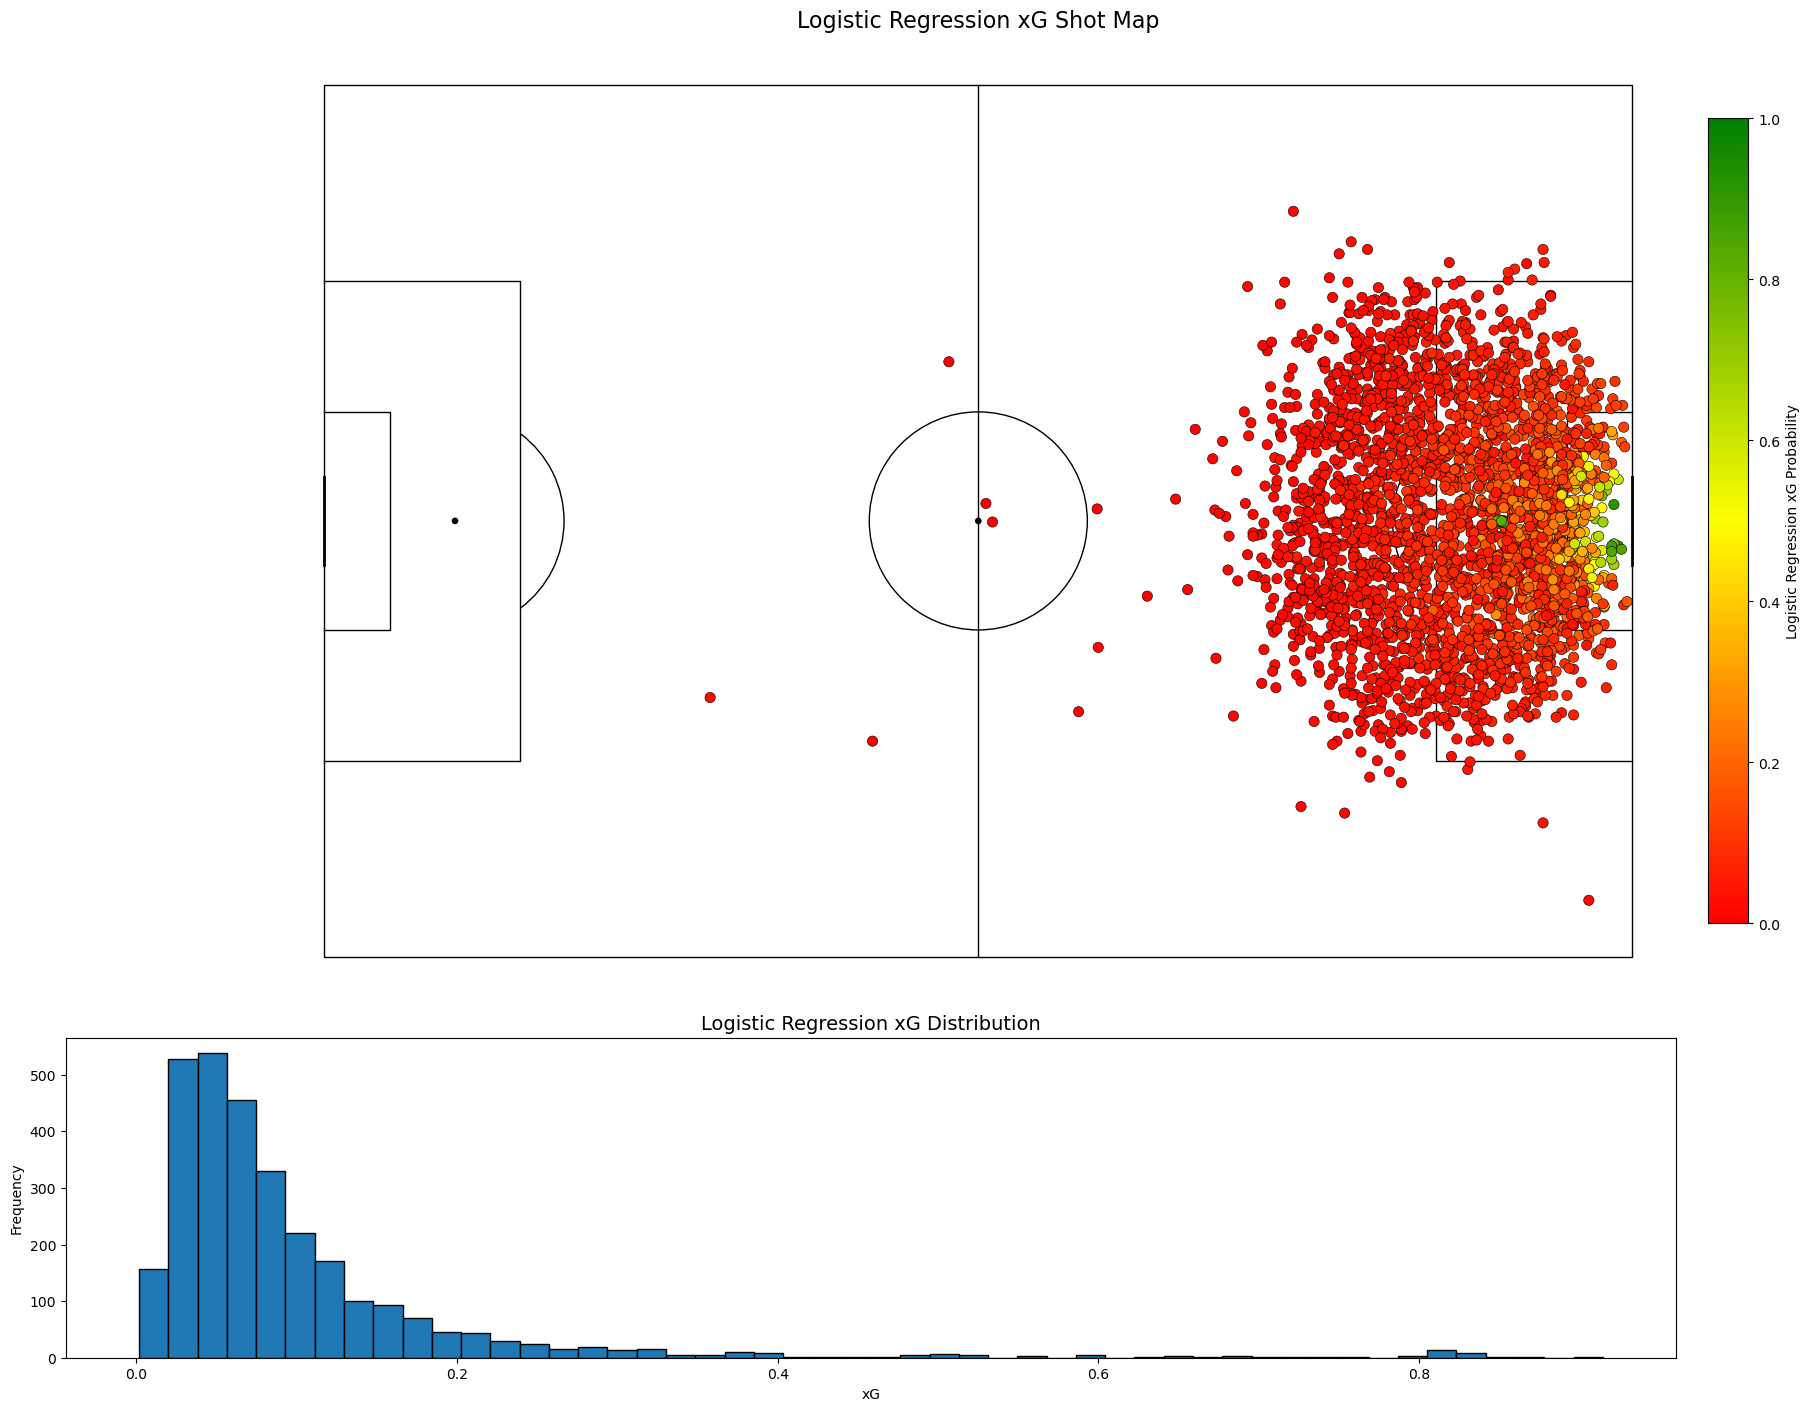

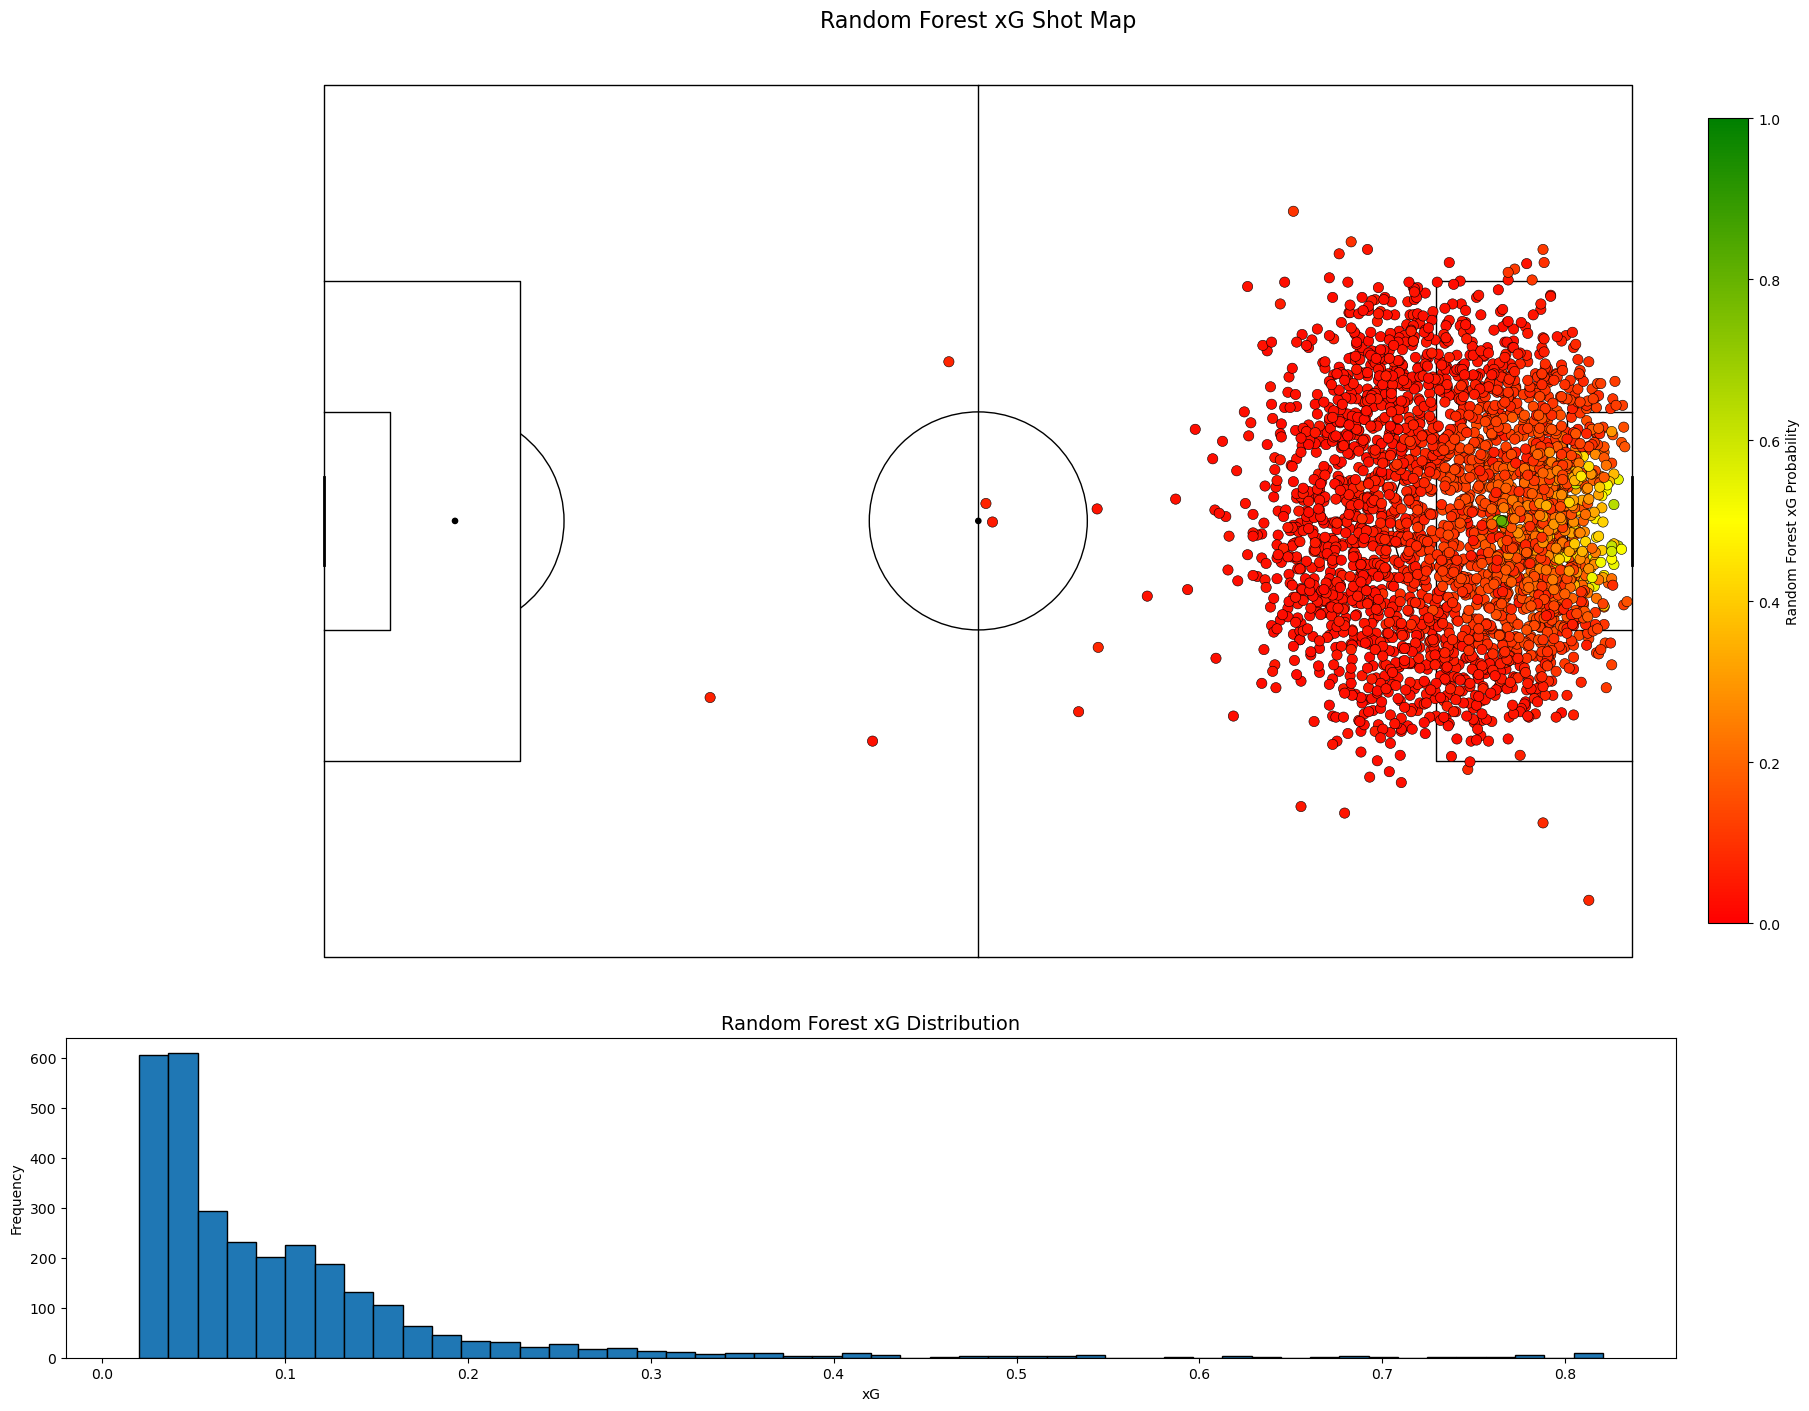

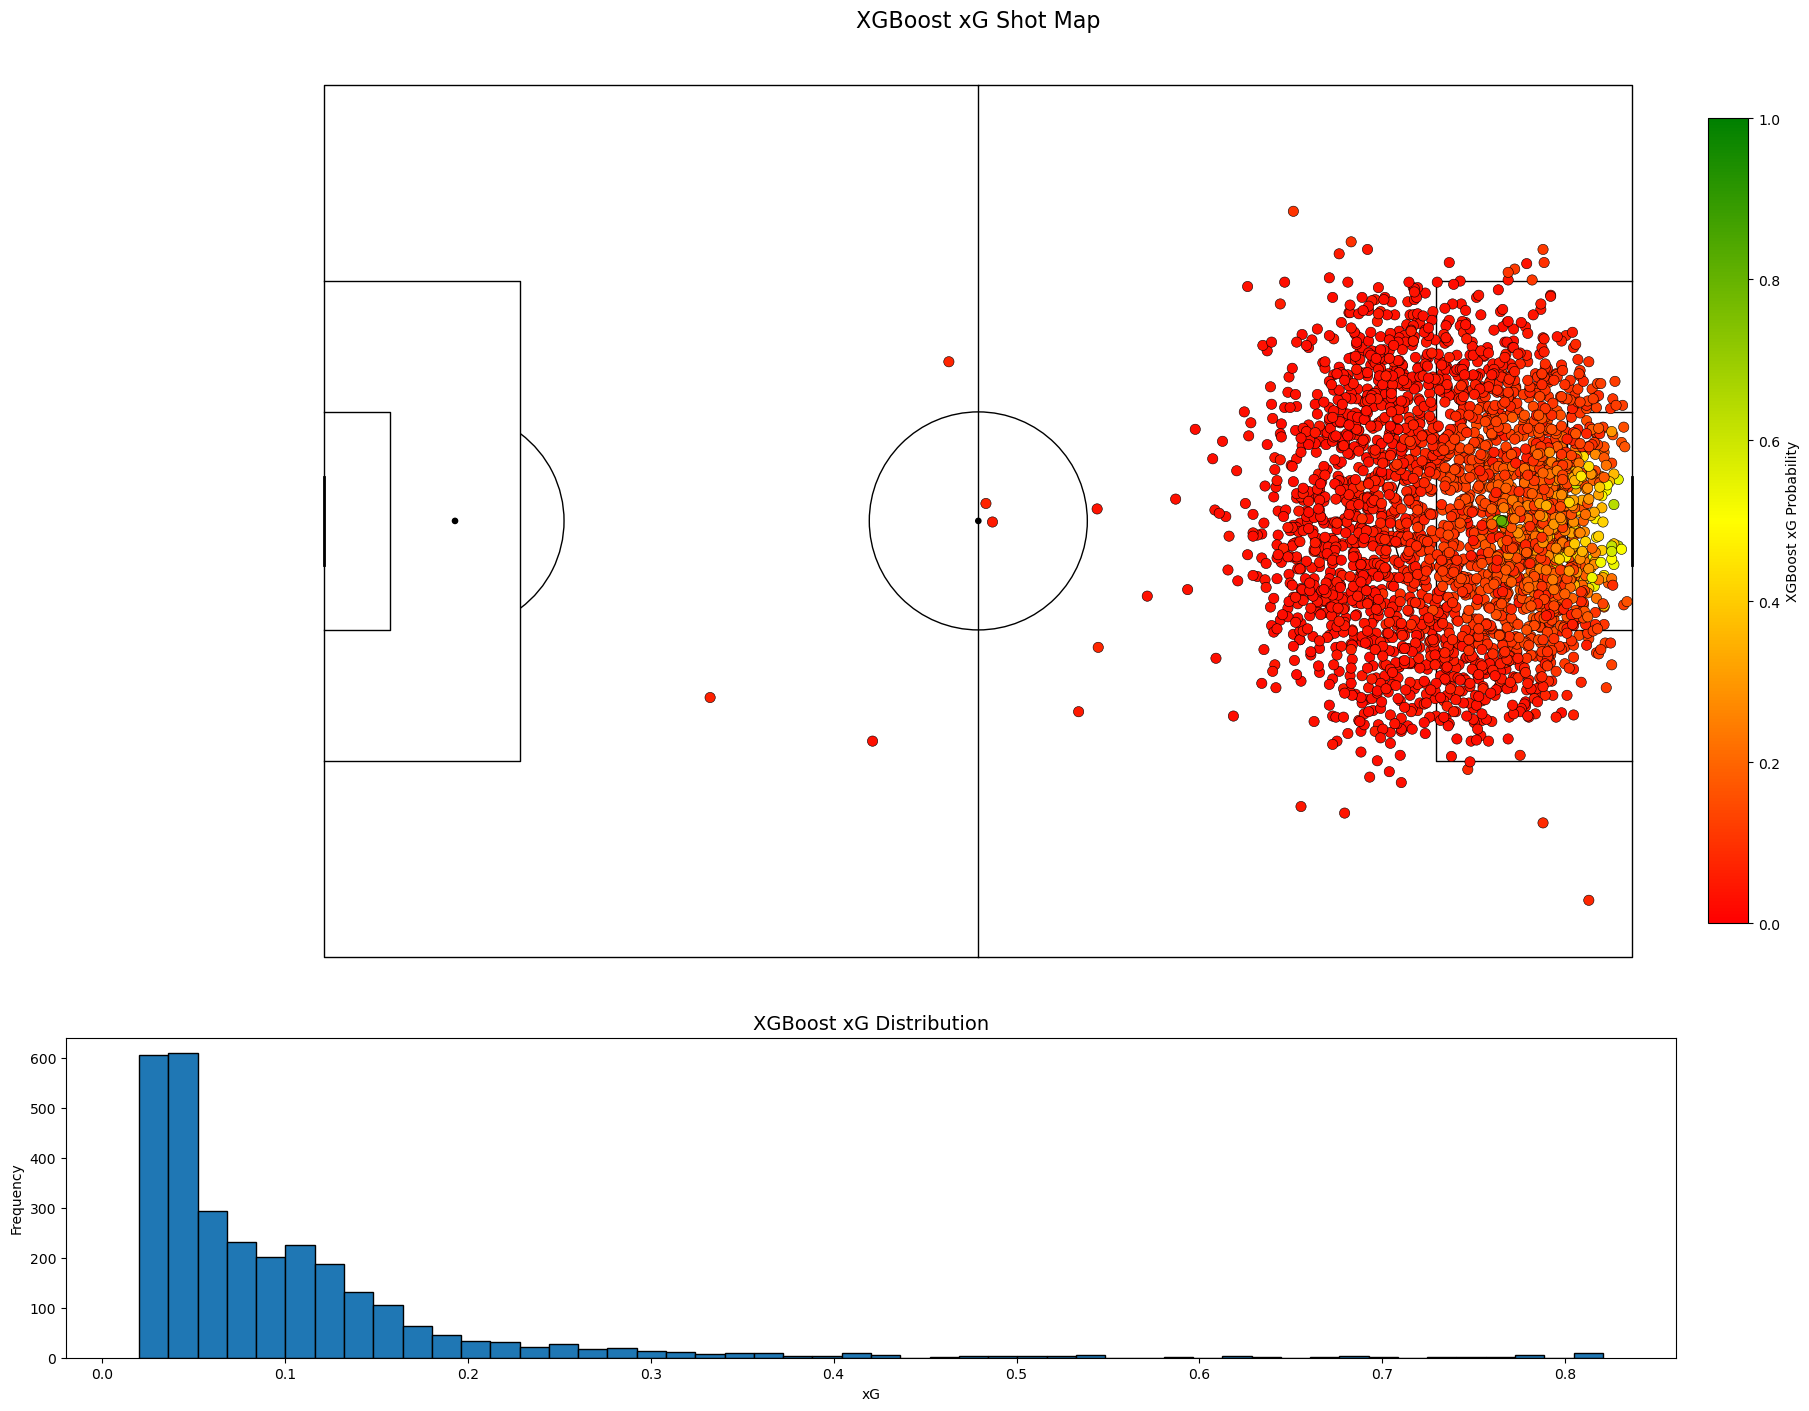

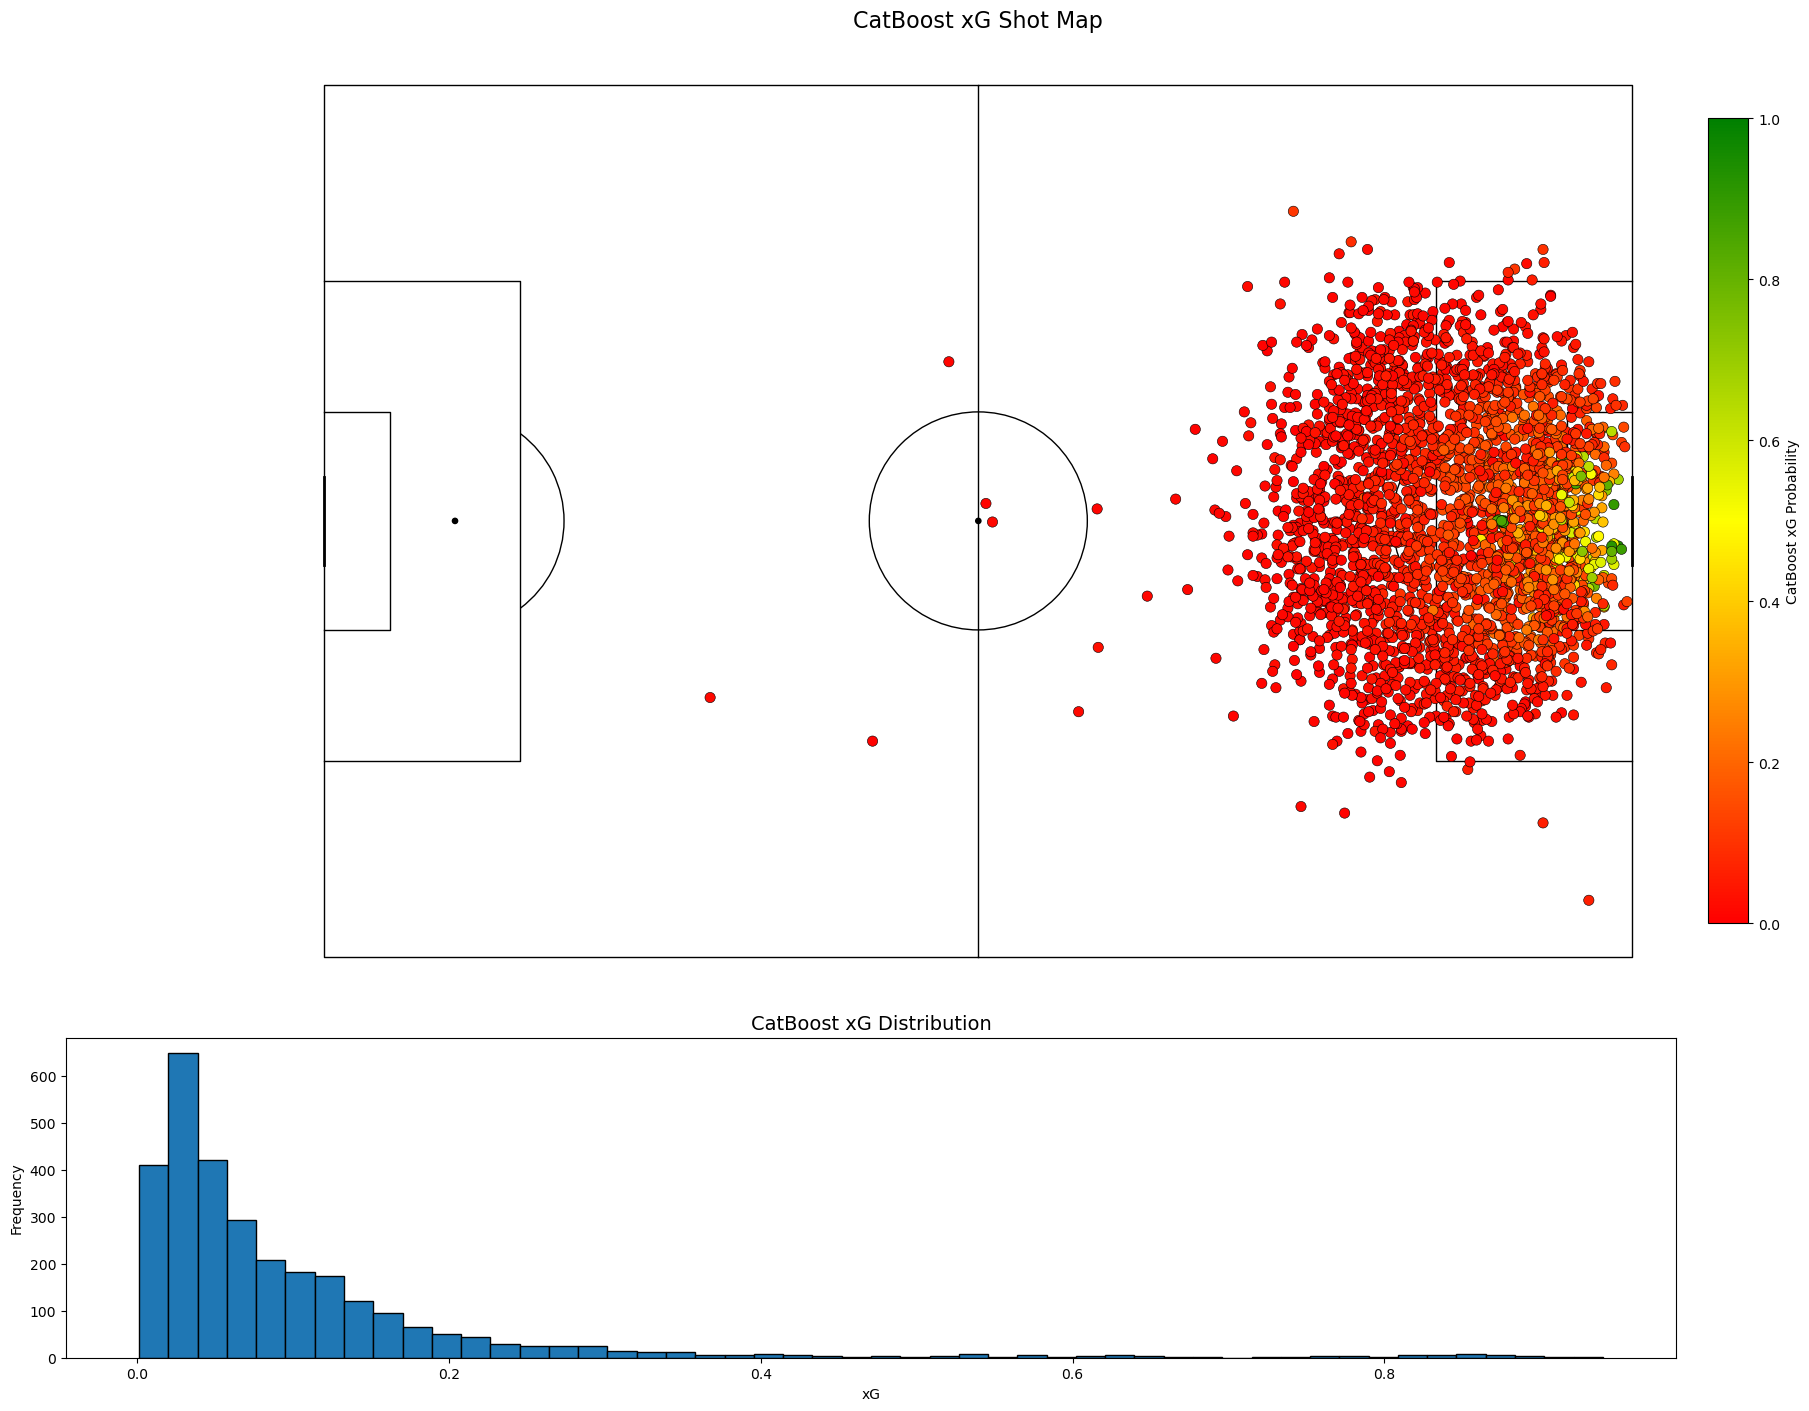

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

dataframes = {
    'Logistic Regression': log_df,
    'Random Forest': rf_df,
    'XGBoost': xgb_df,
    'CatBoost': cat_df
}

for name, df in dataframes.items():

    fig = plt.figure(figsize=(18, 14), constrained_layout=True)

    gs = GridSpec(
        2, 1,
        height_ratios=[3, 1],
        figure=fig
    )

    ax_pitch = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1])

    # ---- TOP: Pitch Plot ----
    pitch.draw(ax=ax_pitch)

    sc = pitch.scatter(
        cordinates['x'],
        cordinates['y'],
        c=df['xG'],
        cmap=cmap,
        edgecolors='black',
        linewidth=0.4,
        s=55,
        vmin=0,
        vmax=1,
        ax=ax_pitch
    )

    ax_pitch.set_title(f'{name} xG Shot Map', fontsize=16, pad=10)

    cbar = fig.colorbar(
        sc,
        ax=ax_pitch,
        fraction=0.025,
        pad=0.02
    )
    cbar.set_label(f'{name} xG Probability')

    # ---- BOTTOM: Histogram ----
    ax_hist.hist(
        df['xG'],
        bins=50,
        edgecolor='black'
    )

    ax_hist.set_title(f'{name} xG Distribution', fontsize=14)
    ax_hist.set_xlabel('xG')
    ax_hist.set_ylabel('Frequency')

    plt.show()

# FOUNDATION MODEL APPROACH

TabPFN

In [61]:
# %conda install -c conda-forge tabpfn 
# %conda install -c conda-forge tabpfn-client
# %pip install tabpfn-client

To use tabpfn:

1. Open https://ux.priorlabs.ai in a browser and log in (or register)
2. Accept the license on the Licenses tab
3. Copy your API Key from https://ux.priorlabs.ai/account
4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
 or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"

or use mine: "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [62]:
# import os

# os.environ["TABPFN_TOKEN"] = "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [63]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token("tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs")
tabPFN = TabPFNClassifier()
tabPFN.fit(X_train, y_train)
goal_tabPFN = tabPFN.predict(X_test)
y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:02 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!


In [64]:
# y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

In [65]:
print(f"Accuracy: {accuracy_score(y_test, goal_tabPFN):.3f}\nLog Loss: {log_loss(y_test, y_tabPFN):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_tabPFN):.3f}\nBrier Score: {brier_score_loss(y_test, y_tabPFN):.3f}")

Accuracy: 0.910
Log Loss: 0.272
ROC_AUC Score: 0.780
Brier Score: 0.076
